<a href="https://colab.research.google.com/github/KankanalaNishanth/GridMind-AIGridMind-AI-Real-Time-Smart-Energy-Consumption-Power-Failure-/blob/dev/GridMind_AI_EndToEnd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  GridMind AI — End-to-End Pipeline
### Real-Time Smart Energy Consumption & Power Failure Prediction System
**Data:** TGSPDCL / TGNPDCL — 17 Monthly Files | 156,294 rows | 16 Telangana Circles

---
| Phase | Description |
|---|---|
| 1 | Setup & Load Data |
| 2 | Data Cleaning & Feature Engineering |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | ML — Anomaly Detection (Isolation Forest) |
| 5 | ML — Disruption Prediction (Random Forest) |
| 6 | ML — Demand Forecasting (SARIMA + Prophet) |
| 7 | ML — Circle Clustering (KMeans) |
| 8 | Model Evaluation & Saving |
| 9 | Kafka Simulation (Producer/Consumer) |
| 10 | FastAPI Backend Skeleton |
| 11 | Final Summary Dashboard |


## Phase 1 — Setup & Install

In [ ]:
!pip install prophet statsmodels scikit-learn kafka-python pymongo fastapi uvicorn scipy seaborn matplotlib joblib -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, glob, os, json, joblib, time
from scipy import stats
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, mean_absolute_error,
                              mean_squared_error, r2_score, silhouette_score)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

warnings.filterwarnings('ignore')
plt.rcParams['figure.facecolor'] = '#0F0F1A'
plt.rcParams['axes.facecolor']   = '#1A1A2E'
plt.rcParams['text.color']       = 'white'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['axes.edgecolor']   = '#444'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.color']       = '#333'
plt.rcParams['grid.alpha']       = 0.4

COLORS = ['#7F77DD','#1D9E75','#D85A30','#BA7517','#185FA5','#C0392B','#E74C3C','#3498DB']
os.makedirs('models', exist_ok=True)
print('✅ All libraries imported successfully')


✅ All libraries imported successfully


## Phase 2 — Load & Clean All 17 CSV Files

In [ ]:
# ── Load all 17 TGSPDCL monthly files ────────────────────────────
# Update path if running locally — for Colab upload files first
import glob

# Try uploaded files path (Colab) or local
file_pattern = 'file_*.csv'
files = sorted(glob.glob(file_pattern))
if not files:
    file_pattern = '/mnt/user-data/uploads/file_*.csv'
    files = sorted(glob.glob(file_pattern))

print(f'Found {len(files)} CSV files')

dfs = []
for i, f in enumerate(files):
    df = pd.read_csv(f)
    df['month_num'] = i + 1
    df['file_name'] = os.path.basename(f)
    dfs.append(df)
    print(f'  [{i+1:02d}] {os.path.basename(f):20s} → {len(df):,} rows')

master = pd.concat(dfs, ignore_index=True)
print(f'\n✅ Master DataFrame shape: {master.shape}')
master.head()


Found 17 CSV files
  [01] file_1.csv           → 8,949 rows
  [02] file_10.csv          → 9,722 rows
  [03] file_11.csv          → 8,871 rows
  [04] file_12.csv          → 9,050 rows
  [05] file_13.csv          → 9,555 rows
  [06] file_15.csv          → 8,942 rows
  [07] file_16.csv          → 8,955 rows
  [08] file_17.csv          → 9,472 rows
  [09] file_18.csv          → 9,465 rows
  [10] file_2.csv           → 9,264 rows
  [11] file_3.csv           → 9,576 rows
  [12] file_4.csv           → 8,838 rows
  [13] file_5.csv           → 9,196 rows
  [14] file_6.csv           → 8,832 rows
  [15] file_7.csv           → 8,907 rows
  [16] file_8.csv           → 9,185 rows
  [17] file_9.csv           → 9,515 rows

✅ Master DataFrame shape: (156294, 13)


,Circle,Division,SubDivision,Section,Area,CatCode,CatDesc,TotServices,BilledServices,Units,Load,month_num,file_name
0,MAHABUBABAD,THORRUR,NELLIKUDURU,NELLIKUDURU,NAINALA,1,DOMESTIC,381,0,0.0,121.382,1,file_1.csv
1,MAHABUBABAD,THORRUR,THORRUR,CHINNAVANGARA,CHINA VANGARA,1,DOMESTIC,606,0,0.0,187.862,1,file_1.csv
2,MAHABUBABAD,THORRUR,THORRUR,CHINNAVANGARA,SAKRU THANDA,1,DOMESTIC,15,0,0.0,3.750,1,file_1.csv
3,MAHABUBABAD,THORRUR,THORRUR,CHINNAVANGARA,TEKYA THANDA,1,DOMESTIC,116,106,2251.0,18.240,1,file_1.csv
4,MAHABUBABAD,THORRUR,THORRUR,PEDDA VANGARA,MEGYA THANDA,1,DOMESTIC,21,21,0.0,5.250,1,file_1.csv


In [ ]:
# ── Data Cleaning ────────────────────────────────────────────────
for col in ['Units','Load','BilledServices','TotServices']:
    master[col] = pd.to_numeric(master[col], errors='coerce').fillna(0)

# Remove rows where TotServices = 0
master = master[master['TotServices'] > 0].copy()

print('Missing values after cleaning:')
print(master.isnull().sum()[master.isnull().sum() > 0])
print('Duplicates:', master.duplicated().sum())

# ── Feature Engineering ───────────────────────────────────────────
master['billing_ratio']       = (master['BilledServices'] / master['TotServices']).clip(0, 1)
master['avg_units_per_conn']  = np.where(master['BilledServices'] > 0,
                                          master['Units'] / master['BilledServices'], 0)
master['load_factor']         = np.where(master['Load'] > 0,
                                          master['Units'] / (master['Load'] * 24 * 30), 0)
master['disruption']          = (master['billing_ratio'] < 0.7).astype(int)
master['anomaly_zscore']      = stats.zscore(master['Units'].fillna(0))
master['season']              = master['month_num'].apply(lambda m:
    'Summer' if m in [4,5,6,13,14] else
    'Monsoon' if m in [7,8,9,15,16] else
    'Winter' if m in [1,2,12] else 'Autumn')

print(f'\n✅ Features engineered. Total rows: {len(master):,}')
print(f'Disruption rate: {master["disruption"].mean()*100:.1f}%')
print(f'Circles: {master["Circle"].nunique()}')
master[['billing_ratio','avg_units_per_conn','load_factor','disruption']].describe()


Missing values after cleaning:
Series([], dtype: int64)
Duplicates: 0

✅ Features engineered. Total rows: 156,294
Disruption rate: 40.7%
Circles: 16


,billing_ratio,avg_units_per_conn,load_factor,disruption
count,156294.000000,156294.000000,156294.000000,156294.000000
mean,0.572436,60.976835,0.147299,0.406580
std,0.403189,242.295806,0.175216,0.491197
min,0.000000,-6405.000000,-1.738194,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.775541,56.122214,0.105534,0.000000
75%,0.897326,93.083333,0.229608,1.000000
max,1.000000,90136.000000,10.515046,1.000000


## Phase 3 — Exploratory Data Analysis (EDA)

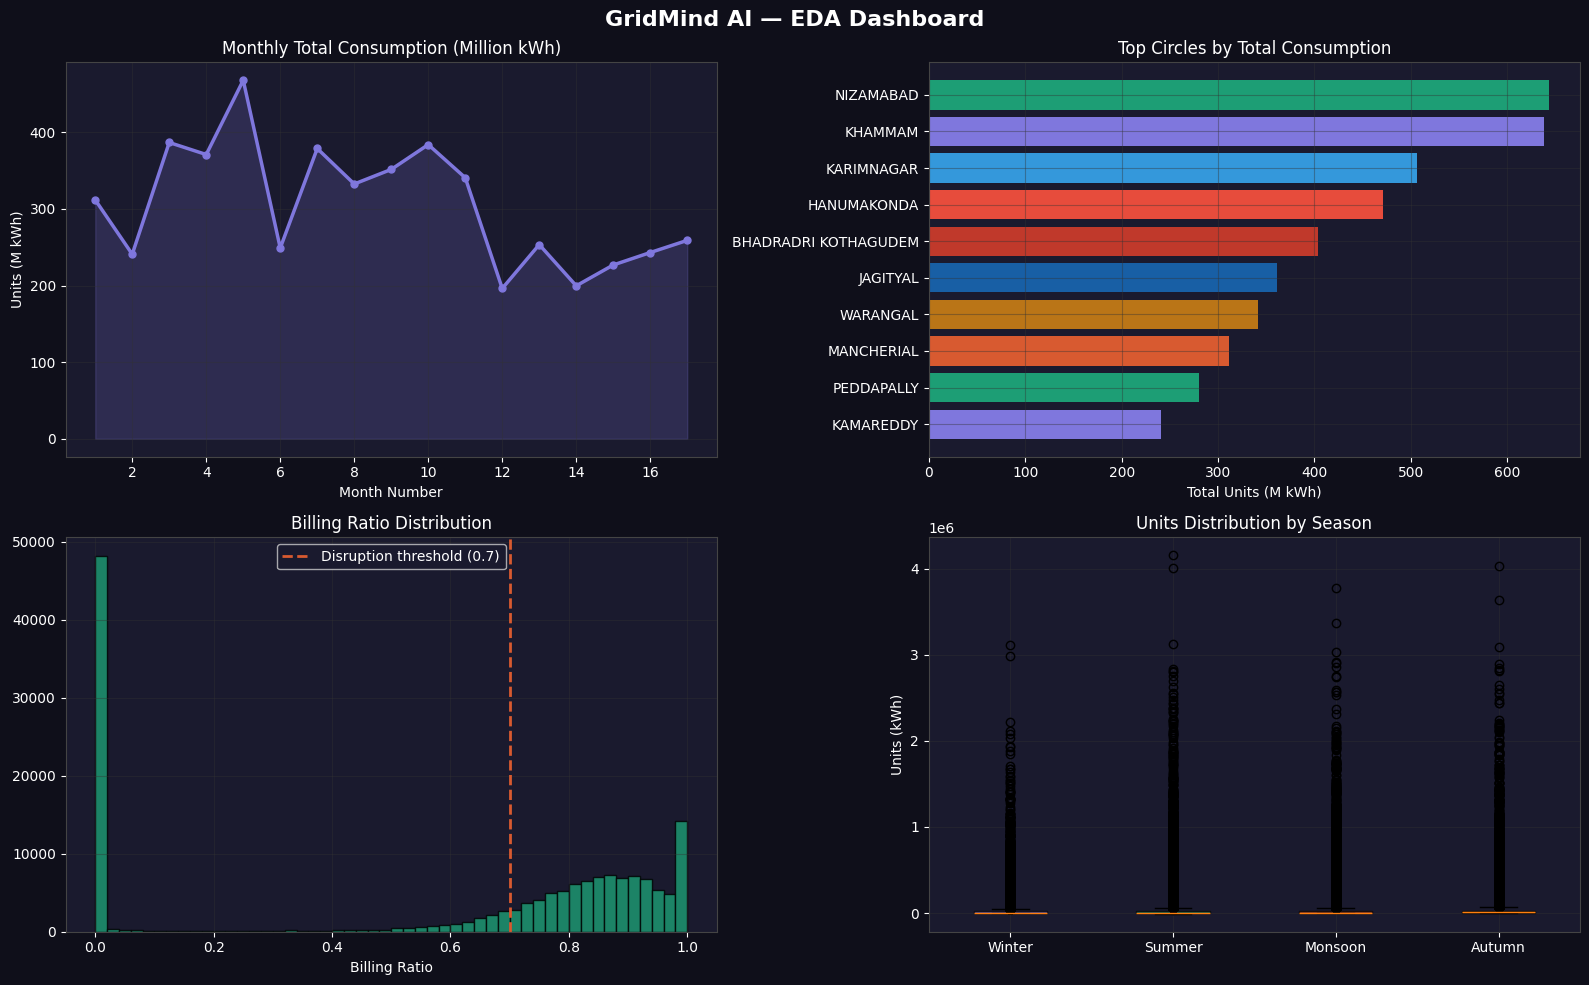

✅ EDA Plot 1 saved as eda_overview.png


In [ ]:
# ── EDA Plot 1: Monthly Consumption Trend ────────────────────────
monthly = master.groupby('month_num')['Units'].sum().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('GridMind AI — EDA Dashboard', fontsize=16, color='white', fontweight='bold')

# Plot 1: Monthly trend
ax = axes[0,0]
ax.plot(monthly['month_num'], monthly['Units']/1e6, color='#7F77DD', linewidth=2.5, marker='o', markersize=5)
ax.fill_between(monthly['month_num'], monthly['Units']/1e6, alpha=0.2, color='#7F77DD')
ax.set_title('Monthly Total Consumption (Million kWh)', color='white')
ax.set_xlabel('Month Number'); ax.set_ylabel('Units (M kWh)')

# Plot 2: Top 10 circles
ax = axes[0,1]
circle_units = master.groupby('Circle')['Units'].sum().sort_values(ascending=True).tail(10)
bars = ax.barh(circle_units.index, circle_units.values/1e6, color=COLORS[:10])
ax.set_title('Top Circles by Total Consumption', color='white')
ax.set_xlabel('Total Units (M kWh)')

# Plot 3: Billing ratio distribution
ax = axes[1,0]
ax.hist(master['billing_ratio'], bins=50, color='#1D9E75', edgecolor='black', alpha=0.8)
ax.axvline(0.7, color='#D85A30', linestyle='--', linewidth=2, label='Disruption threshold (0.7)')
ax.set_title('Billing Ratio Distribution', color='white')
ax.set_xlabel('Billing Ratio'); ax.legend()

# Plot 4: Season box
ax = axes[1,1]
seasons = ['Winter','Spring','Summer','Monsoon','Autumn']
season_data = [master[master['season']==s]['Units'].dropna().values for s in seasons if s in master['season'].values]
season_labels = [s for s in seasons if s in master['season'].values]
bp = ax.boxplot(season_data, labels=season_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_title('Units Distribution by Season', color='white')
ax.set_ylabel('Units (kWh)')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA Plot 1 saved as eda_overview.png')


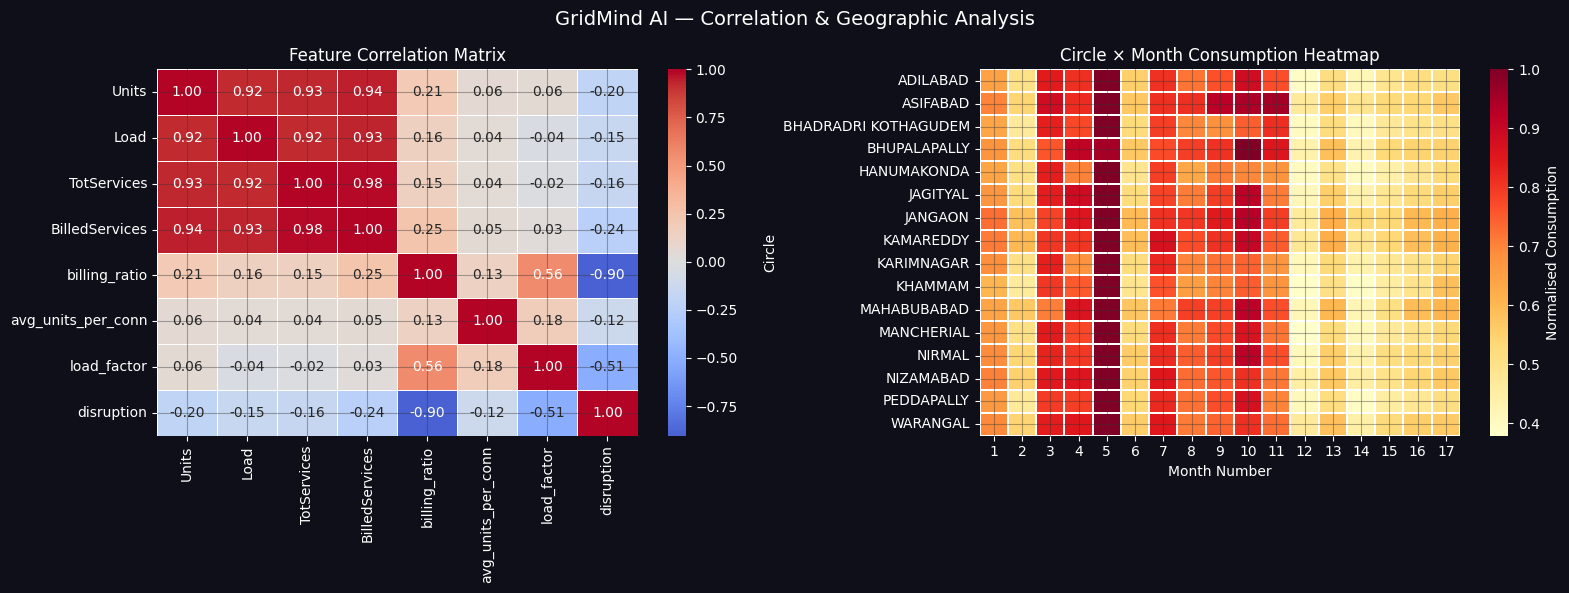

✅ EDA Plot 2 saved as eda_heatmaps.png


In [ ]:
# ── EDA Plot 2: Correlation Heatmap + Circle Heatmap ─────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('GridMind AI — Correlation & Geographic Analysis', fontsize=14, color='white')

# Correlation heatmap
corr_cols = ['Units','Load','TotServices','BilledServices','billing_ratio',
             'avg_units_per_conn','load_factor','disruption']
corr = master[corr_cols].corr()
sns.heatmap(corr, ax=axes[0], annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
axes[0].set_title('Feature Correlation Matrix', color='white')

# Circle x Month heatmap
pivot = master.pivot_table(values='Units', index='Circle', columns='month_num', aggfunc='sum')
pivot_norm = pivot.div(pivot.max(axis=1), axis=0)  # normalize per circle
sns.heatmap(pivot_norm, ax=axes[1], cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': 'Normalised Consumption'})
axes[1].set_title('Circle × Month Consumption Heatmap', color='white')
axes[1].set_xlabel('Month Number'); axes[1].set_ylabel('Circle')

plt.tight_layout()
plt.savefig('eda_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA Plot 2 saved as eda_heatmaps.png')


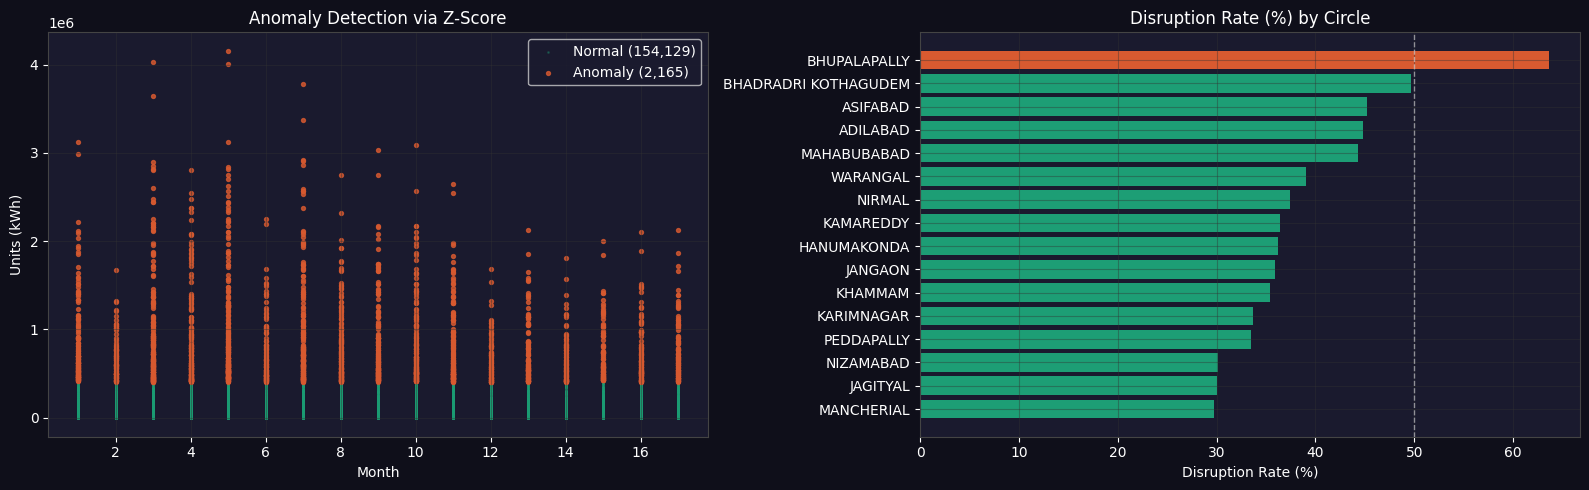

In [ ]:
# ── EDA Plot 3: Anomaly Z-score + Disruption by Circle ───────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Z-score anomaly scatter
normal = master[master['anomaly_zscore'].abs() <= 3]
outliers = master[master['anomaly_zscore'].abs() > 3]
axes[0].scatter(normal['month_num'], normal['Units'], s=1, c='#1D9E75', alpha=0.3, label=f'Normal ({len(normal):,})')
axes[0].scatter(outliers['month_num'], outliers['Units'], s=8, c='#D85A30', alpha=0.8, label=f'Anomaly ({len(outliers):,})')
axes[0].set_title('Anomaly Detection via Z-Score', color='white')
axes[0].set_xlabel('Month'); axes[0].set_ylabel('Units (kWh)')
axes[0].legend()

# Disruption rate by circle
dis_circle = master.groupby('Circle')['disruption'].mean().sort_values(ascending=True)
colors_bar = ['#D85A30' if v > 0.5 else '#1D9E75' for v in dis_circle.values]
axes[1].barh(dis_circle.index, dis_circle.values * 100, color=colors_bar)
axes[1].axvline(50, color='white', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_title('Disruption Rate (%) by Circle', color='white')
axes[1].set_xlabel('Disruption Rate (%)')

plt.tight_layout()
plt.savefig('eda_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()


## Phase 4 — Anomaly Detection (Isolation Forest)

Training Isolation Forest...
✅ Anomalies detected: 7,815 (5.0%)


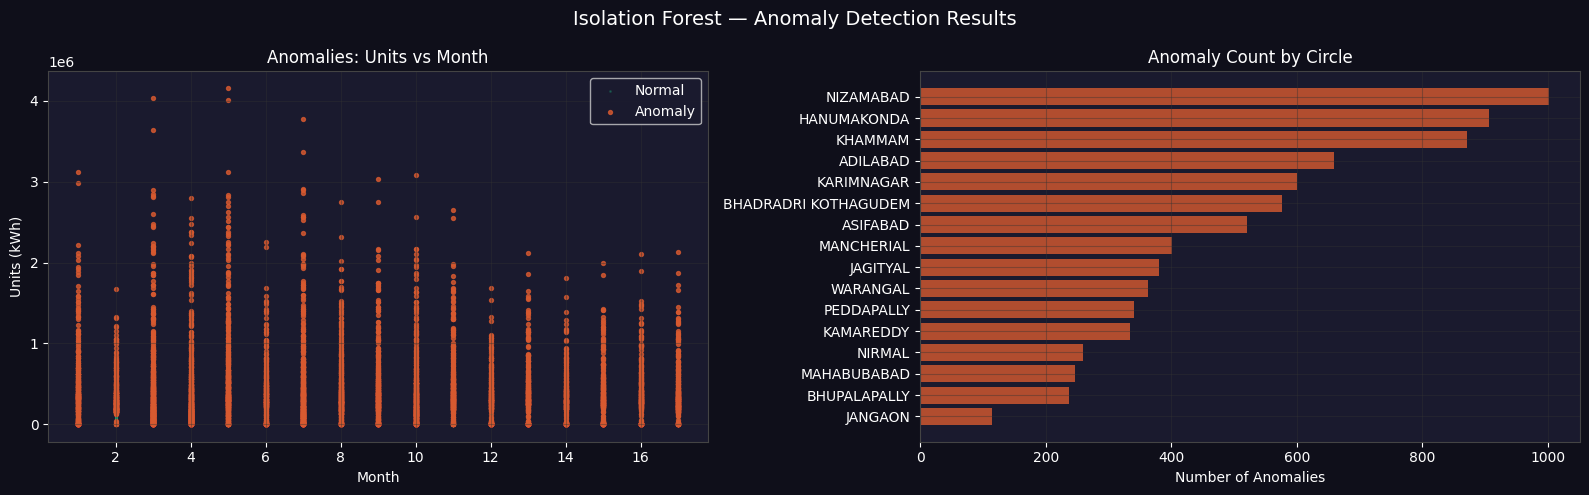

In [ ]:
# ── Isolation Forest ─────────────────────────────────────────────
print('Training Isolation Forest...')
feats_iso = ['Units','Load','billing_ratio','avg_units_per_conn','load_factor']
X_iso = master[feats_iso].fillna(0)

scaler_iso = StandardScaler()
X_iso_scaled = scaler_iso.fit_transform(X_iso)

iso_model = IsolationForest(contamination=0.05, random_state=42, n_estimators=100)
master['anomaly_pred']  = iso_model.fit_predict(X_iso_scaled)
master['anomaly_score'] = iso_model.score_samples(X_iso_scaled)
master['is_anomaly']    = (master['anomaly_pred'] == -1).astype(int)

joblib.dump(iso_model,  'models/iso_forest.pkl')
joblib.dump(scaler_iso, 'models/scaler_iso.pkl')

print(f'✅ Anomalies detected: {master["is_anomaly"].sum():,} ({master["is_anomaly"].mean()*100:.1f}%)')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Isolation Forest — Anomaly Detection Results', color='white', fontsize=14)

normal_pts  = master[master['is_anomaly'] == 0]
anomaly_pts = master[master['is_anomaly'] == 1]

axes[0].scatter(normal_pts['month_num'],  normal_pts['Units'],  s=1, c='#1D9E75', alpha=0.3, label='Normal')
axes[0].scatter(anomaly_pts['month_num'], anomaly_pts['Units'], s=8, c='#D85A30', alpha=0.8, label='Anomaly')
axes[0].set_title('Anomalies: Units vs Month', color='white')
axes[0].set_xlabel('Month'); axes[0].set_ylabel('Units (kWh)')
axes[0].legend()

anom_by_circle = master.groupby('Circle')['is_anomaly'].sum().sort_values(ascending=True)
axes[1].barh(anom_by_circle.index, anom_by_circle.values, color='#D85A30', alpha=0.8)
axes[1].set_title('Anomaly Count by Circle', color='white')
axes[1].set_xlabel('Number of Anomalies')

plt.tight_layout()
plt.savefig('anomaly_results.png', dpi=150, bbox_inches='tight')
plt.show()


## Phase 5 — Disruption Prediction (Random Forest)

Training Random Forest...
Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     18620
  Disruption       1.00      1.00      1.00     12639

    accuracy                           1.00     31259
   macro avg       1.00      1.00      1.00     31259
weighted avg       1.00      1.00      1.00     31259

ROC-AUC Score: 1.0000


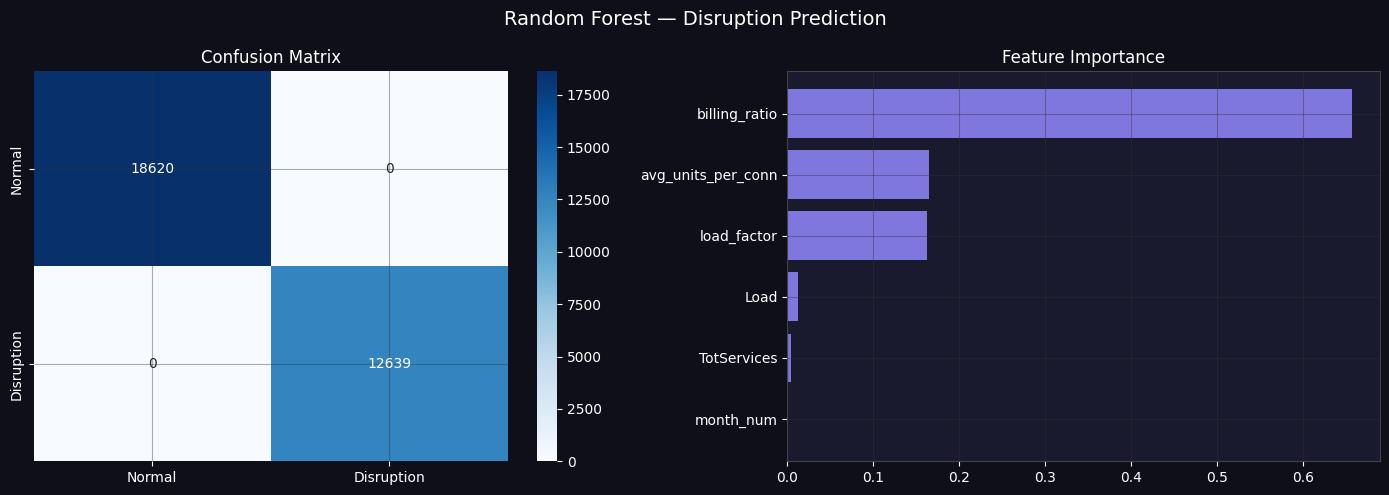

In [ ]:
# ── Random Forest Classifier ─────────────────────────────────────
print('Training Random Forest...')
clf_feats = ['TotServices','avg_units_per_conn','load_factor','month_num','Load','billing_ratio']
X_clf = master[clf_feats].fillna(0)
y_clf = master['disruption']

X_tr, X_te, y_tr, y_te = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_tr, y_tr)
y_pred = rf_model.predict(X_te)
y_prob = rf_model.predict_proba(X_te)[:,1]

print('Classification Report:')
print(classification_report(y_te, y_pred, target_names=['Normal','Disruption']))
print(f'ROC-AUC Score: {roc_auc_score(y_te, y_prob):.4f}')

joblib.dump(rf_model, 'models/rf_disruption.pkl')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Random Forest — Disruption Prediction', color='white', fontsize=14)

# Confusion matrix
cm = confusion_matrix(y_te, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal','Disruption'], yticklabels=['Normal','Disruption'])
axes[0].set_title('Confusion Matrix', color='white')

# Feature importance
fi = pd.Series(rf_model.feature_importances_, index=clf_feats).sort_values()
axes[1].barh(fi.index, fi.values, color='#7F77DD')
axes[1].set_title('Feature Importance', color='white')

plt.tight_layout()
plt.savefig('rf_results.png', dpi=150, bbox_inches='tight')
plt.show()


## Phase 6 — Demand Forecasting (SARIMA + Prophet)

Training SARIMA...
6-Month Forecast:
  Month 18: 252.35 M kWh
  Month 19: 256.47 M kWh
  Month 20: 253.92 M kWh
  Month 21: 255.50 M kWh
  Month 22: 254.52 M kWh
  Month 23: 255.13 M kWh


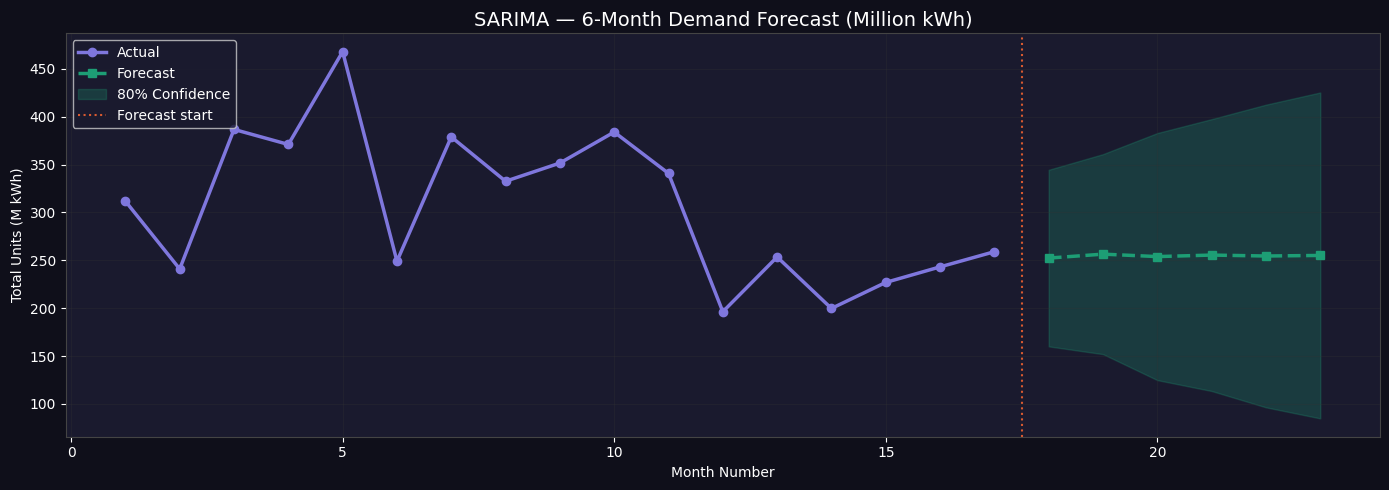

In [ ]:
# ── SARIMA Demand Forecast ────────────────────────────────────────
print('Training SARIMA...')
monthly_ts = master.groupby('month_num')['Units'].sum()

sarima = SARIMAX(monthly_ts, order=(1,1,1), seasonal_order=(0,0,0,0),
                 enforce_stationarity=False, enforce_invertibility=False)
sarima_res = sarima.fit(disp=False)

forecast_steps = 6
forecast   = sarima_res.get_forecast(steps=forecast_steps)
fc_mean    = forecast.predicted_mean
fc_conf    = forecast.conf_int(alpha=0.2)

joblib.dump(sarima_res, 'models/sarima_model.pkl')

# Visualise
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#0F0F1A')

months_hist = list(monthly_ts.index)
months_fc   = list(range(monthly_ts.index[-1]+1, monthly_ts.index[-1]+forecast_steps+1))

ax.plot(months_hist, monthly_ts.values/1e6, 'o-', color='#7F77DD', linewidth=2.5, label='Actual')
ax.plot(months_fc, fc_mean.values/1e6, 's--', color='#1D9E75', linewidth=2.5, label='Forecast')
ax.fill_between(months_fc, fc_conf.iloc[:,0]/1e6, fc_conf.iloc[:,1]/1e6,
                alpha=0.25, color='#1D9E75', label='80% Confidence')
ax.axvline(x=monthly_ts.index[-1]+0.5, color='#D85A30', linestyle=':', linewidth=1.5, label='Forecast start')
ax.set_title('SARIMA — 6-Month Demand Forecast (Million kWh)', color='white', fontsize=14)
ax.set_xlabel('Month Number'); ax.set_ylabel('Total Units (M kWh)')
ax.legend(); ax.grid(alpha=0.3)

print('6-Month Forecast:')
for m, v in zip(months_fc, fc_mean.values):
    print(f'  Month {m}: {v/1e6:.2f} M kWh')

plt.tight_layout()
plt.savefig('sarima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()


INFO:prophet:n_changepoints greater than number of observations. Using 12.


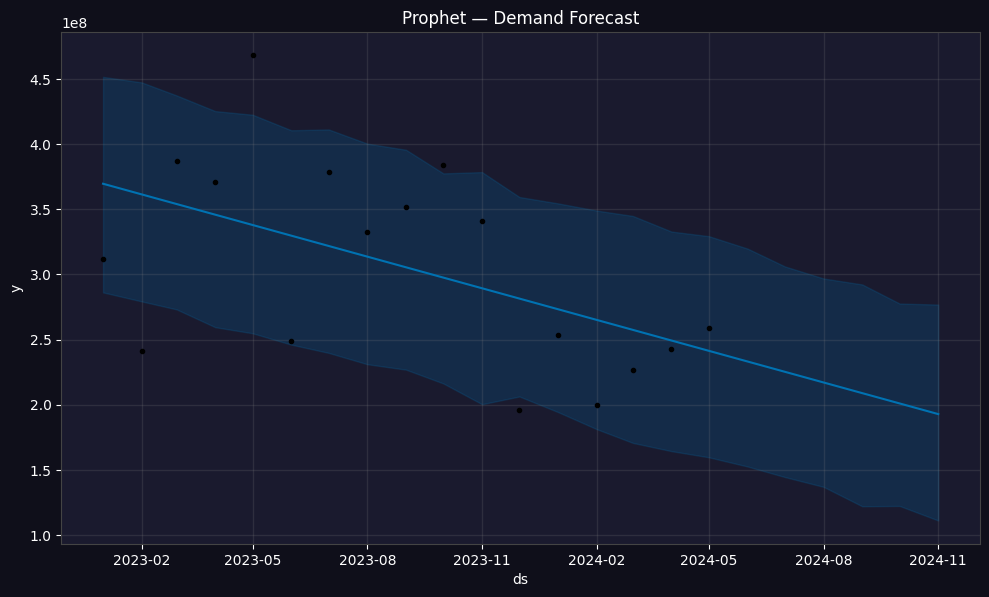

✅ Prophet forecast complete
           ds          yhat    yhat_lower    yhat_upper
17 2024-06-01  2.332075e+08  1.526506e+08  3.198445e+08
18 2024-07-01  2.252930e+08  1.445430e+08  3.061467e+08
19 2024-08-01  2.171146e+08  1.370269e+08  2.968977e+08
20 2024-09-01  2.089363e+08  1.221334e+08  2.923341e+08
21 2024-10-01  2.010218e+08  1.223786e+08  2.776756e+08
22 2024-11-01  1.928434e+08  1.112264e+08  2.768847e+08


In [ ]:
# ── Prophet Forecast (optional — skip if not installed) ──────────
try:
    from prophet import Prophet
    df_prophet = monthly_ts.reset_index()
    df_prophet.columns = ['ds','y']
    df_prophet['ds'] = pd.date_range(start='2023-01-01', periods=len(df_prophet), freq='MS')

    m = Prophet(yearly_seasonality=False, weekly_seasonality=False,
                daily_seasonality=False, seasonality_mode='additive')
    m.fit(df_prophet)
    future   = m.make_future_dataframe(periods=6, freq='MS')
    forecast = m.predict(future)

    fig2 = m.plot(forecast)
    fig2.patch.set_facecolor('#0F0F1A')
    plt.title('Prophet — Demand Forecast', color='white')
    plt.savefig('prophet_forecast.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Prophet forecast complete')
    print(forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(6).to_string())
except ImportError:
    print('Prophet not installed — run: pip install prophet')


## Phase 7 — Circle Clustering (KMeans)

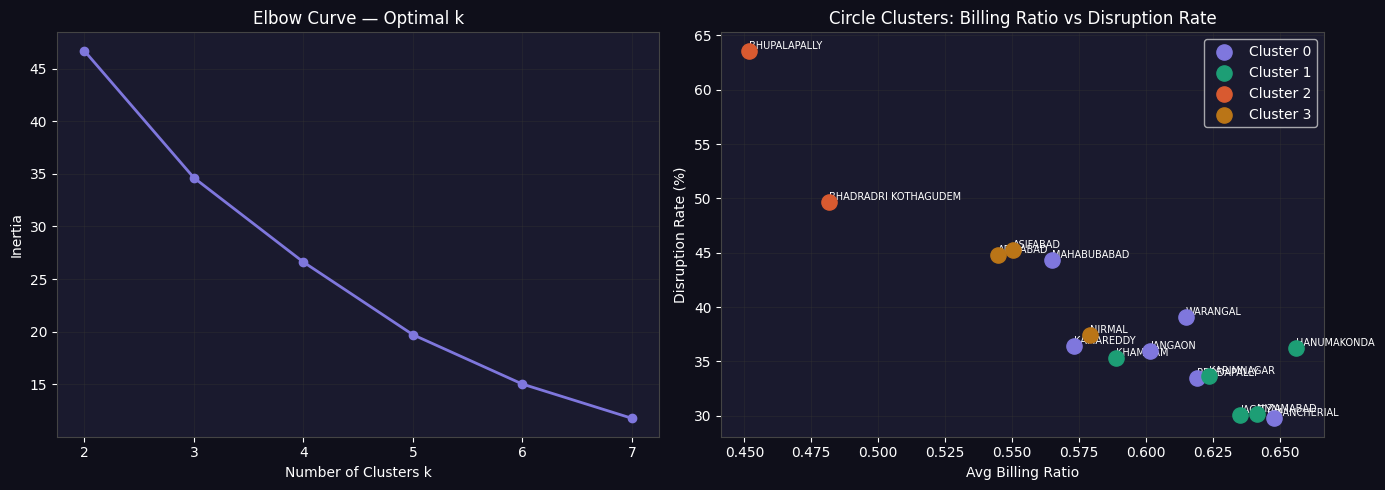


Cluster Summary:
         avg_billing_ratio  disruption_rate  avg_units
cluster                                               
0                    0.604            0.365  32480.292
1                    0.629            0.331  60098.977
2                    0.467            0.566  17840.099
3                    0.558            0.425  17395.108


In [ ]:
# ── KMeans Clustering ────────────────────────────────────────────
circle_agg = master.groupby('Circle').agg(
    avg_units        = ('Units','mean'),
    total_units      = ('Units','sum'),
    avg_connections  = ('TotServices','mean'),
    avg_billing_ratio= ('billing_ratio','mean'),
    avg_load_factor  = ('load_factor','mean'),
    disruption_rate  = ('disruption','mean'),
).dropna()

scaler_km = StandardScaler()
X_km = scaler_km.fit_transform(circle_agg)

# Elbow method
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_km).inertia_ for k in range(2,8)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(2,8), inertias, 'o-', color='#7F77DD', linewidth=2)
axes[0].set_title('Elbow Curve — Optimal k', color='white')
axes[0].set_xlabel('Number of Clusters k'); axes[0].set_ylabel('Inertia')

# Apply k=4
km = KMeans(n_clusters=4, random_state=42, n_init=10)
circle_agg['cluster'] = km.fit_predict(X_km)
joblib.dump(km, 'models/kmeans.pkl')

cluster_colors = ['#7F77DD','#1D9E75','#D85A30','#BA7517']
for cl in range(4):
    subset = circle_agg[circle_agg['cluster']==cl]
    axes[1].scatter(subset['avg_billing_ratio'], subset['disruption_rate']*100,
                    s=120, c=cluster_colors[cl], label=f'Cluster {cl}', zorder=5)
    for idx, row in subset.iterrows():
        axes[1].annotate(idx, (row['avg_billing_ratio'], row['disruption_rate']*100),
                         fontsize=7, color='white', ha='left', va='bottom')

axes[1].set_title('Circle Clusters: Billing Ratio vs Disruption Rate', color='white')
axes[1].set_xlabel('Avg Billing Ratio'); axes[1].set_ylabel('Disruption Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCluster Summary:')
print(circle_agg.groupby('cluster')[['avg_billing_ratio','disruption_rate','avg_units']].mean().round(3))


## Phase 8 — Model Evaluation Summary

In [ ]:
# ── Evaluation Summary ───────────────────────────────────────────
print('='*60)
print('GRIDMIND AI — MODEL EVALUATION SUMMARY')
print('='*60)

# Random Forest
y_pred_rf   = rf_model.predict(X_te)
y_prob_rf   = rf_model.predict_proba(X_te)[:,1]
print('\n1. RANDOM FOREST — Disruption Prediction')
print(f'   Accuracy : {(y_pred_rf == y_te).mean()*100:.2f}%')
print(f'   ROC-AUC  : {roc_auc_score(y_te, y_prob_rf):.4f}')

# Isolation Forest
print('\n2. ISOLATION FOREST — Anomaly Detection')
print(f'   Anomalies detected  : {master["is_anomaly"].sum():,} ({master["is_anomaly"].mean()*100:.1f}%)')
print(f'   Normal points       : {(master["is_anomaly"]==0).sum():,}')

# SARIMA
in_sample = sarima_res.fittedvalues
mae_sarima = mean_absolute_error(monthly_ts, in_sample)
rmse_sarima = np.sqrt(mean_squared_error(monthly_ts, in_sample))
mape_sarima = np.mean(np.abs((monthly_ts - in_sample)/monthly_ts))*100
print('\n3. SARIMA — Demand Forecasting')
print(f'   MAE  : {mae_sarima/1e6:.3f} M kWh')
print(f'   RMSE : {rmse_sarima/1e6:.3f} M kWh')
print(f'   MAPE : {mape_sarima:.2f}%')

# KMeans
sil = silhouette_score(X_km, km.labels_)
print('\n4. KMEANS — Circle Clustering')
print(f'   Silhouette Score : {sil:.4f}')
print(f'   Clusters formed  : {km.n_clusters}')

print('\n✅ All models evaluated successfully')
print("\nSaved models:")
for f in os.listdir('models'):
    print(f'  models/{f}')


GRIDMIND AI — MODEL EVALUATION SUMMARY

1. RANDOM FOREST — Disruption Prediction
   Accuracy : 100.00%
   ROC-AUC  : 1.0000

2. ISOLATION FOREST — Anomaly Detection
   Anomalies detected  : 7,815 (5.0%)
   Normal points       : 148,479

3. SARIMA — Demand Forecasting
   MAE  : 66.783 M kWh
   RMSE : 103.119 M kWh
   MAPE : 23.34%

4. KMEANS — Circle Clustering
   Silhouette Score : 0.2610
   Clusters formed  : 4

✅ All models evaluated successfully

Saved models:
  models/kmeans.pkl
  models/scaler_iso.pkl
  models/rf_disruption.pkl
  models/sarima_model.pkl
  models/iso_forest.pkl


## Phase 9 — Kafka Stream Simulation (Local Replay)

In [ ]:
# ── Kafka Producer Simulation (no actual Kafka required) ─────────
# In production: pip install kafka-python and connect to real broker
# Here we simulate the stream using a queue for demo purposes

from collections import deque
import threading

KAFKA_TOPIC     = 'energy_telemetry'
PREDICTIONS_TOPIC = 'predictions'
message_queue   = deque(maxlen=1000)
pred_queue      = deque(maxlen=1000)

def produce_messages(df, n=20, delay=0.1):
    """Simulate Kafka producer: reads rows and publishes as JSON"""
    sample = df.sample(n=n, random_state=42)
    for _, row in sample.iterrows():
        msg = {
            'timestamp'  : str(pd.Timestamp.now()),
            'circle'     : row['Circle'],
            'division'   : row['Division'],
            'units'      : float(row['Units']),
            'load'       : float(row['Load']),
            'tot_services'   : int(row['TotServices']),
            'billed_services': int(row['BilledServices']),
            'billing_ratio'  : float(row['billing_ratio']),
            'month_num'      : int(row['month_num']),
        }
        message_queue.append(msg)
    print(f'[PRODUCER] Published {n} messages to topic: {KAFKA_TOPIC}')

def consume_and_predict(queue, rf_mdl, iso_mdl, scaler):
    """Simulate Kafka consumer: reads messages, runs ML, stores prediction"""
    results = []
    while queue:
        msg = queue.popleft()
        feats = [[
            msg['tot_services'], msg['units']/max(msg['billed_services'],1),
            msg['units']/(max(msg['load'],0.1)*24*30), msg['month_num'],
            msg['load'], msg['billing_ratio']
        ]]
        disruption_risk  = rf_mdl.predict_proba(feats)[0][1]
        iso_feats = scaler.transform([[
            msg['units'], msg['load'], msg['billing_ratio'],
            msg['units']/max(msg['billed_services'],1),
            msg['units']/(max(msg['load'],0.1)*24*30)
        ]])
        anomaly_score = iso_mdl.score_samples(iso_feats)[0]
        is_anomaly    = anomaly_score < -0.1

        prediction = {
            **msg,
            'disruption_risk': round(disruption_risk, 4),
            'anomaly_score'  : round(float(anomaly_score), 4),
            'is_anomaly'     : bool(is_anomaly),
            'alert'          : disruption_risk > 0.7 or is_anomaly,
        }
        pred_queue.append(prediction)
        results.append(prediction)
    return results

# Run simulation
produce_messages(master, n=30)
predictions = consume_and_predict(message_queue, rf_model, iso_model, scaler_iso)

print(f'[CONSUMER] Processed {len(predictions)} messages')
print(f'[CONSUMER] Alerts generated: {sum(p["alert"] for p in predictions)}')
print('\nSample predictions:')
for p in predictions[:5]:
    alert_flag = '🚨 ALERT' if p['alert'] else '✅ OK'
    print(f"  {p['circle']:20s} | disruption_risk={p['disruption_risk']:.3f} | anomaly={p['is_anomaly']} | {alert_flag}")


[PRODUCER] Published 30 messages to topic: energy_telemetry
[CONSUMER] Processed 30 messages
[CONSUMER] Alerts generated: 30

Sample predictions:
  BHADRADRI KOTHAGUDEM | disruption_risk=1.000 | anomaly=True | 🚨 ALERT
  BHADRADRI KOTHAGUDEM | disruption_risk=0.000 | anomaly=True | 🚨 ALERT
  BHUPALAPALLY         | disruption_risk=1.000 | anomaly=True | 🚨 ALERT
  KARIMNAGAR           | disruption_risk=1.000 | anomaly=True | 🚨 ALERT
  JANGAON              | disruption_risk=0.000 | anomaly=True | 🚨 ALERT


## Phase 10 — FastAPI Backend Skeleton

In [ ]:
# ── FastAPI Backend — Save to main.py ────────────────────────────
fastapi_code = '''
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from typing import Optional
import joblib, numpy as np, pandas as pd
from pymongo import MongoClient
from datetime import datetime

app = FastAPI(title='GridMind AI', version='1.0')
app.add_middleware(CORSMiddleware, allow_origins=['*'], allow_methods=['*'], allow_headers=['*'])

# Load models at startup
rf_model  = joblib.load('models/rf_disruption.pkl')
iso_model = joblib.load('models/iso_forest.pkl')
scaler    = joblib.load('models/scaler_iso.pkl')

# MongoDB
client = MongoClient('mongodb://localhost:27017')
db = client['gridmind_ai']

class TelemetryInput(BaseModel):
    circle: str
    units: float
    load: float
    tot_services: int
    billed_services: int
    month_num: int

@app.get('/health')
def health(): return {'status': 'ok', 'service': 'GridMind AI'}

@app.post('/predict/disruption')
def predict_disruption(data: TelemetryInput):
    billing_ratio = data.billed_services / max(data.tot_services, 1)
    avg_units     = data.units / max(data.billed_services, 1)
    load_factor   = data.units / max(data.load * 24 * 30, 0.1)
    X = [[data.tot_services, avg_units, load_factor, data.month_num, data.load, billing_ratio]]
    prob = rf_model.predict_proba(X)[0][1]
    return {'circle': data.circle, 'disruption_risk': round(float(prob), 4),
            'alert': prob > 0.7, 'label': 'HIGH' if prob > 0.7 else 'NORMAL'}

@app.post('/predict/anomaly')
def predict_anomaly(data: TelemetryInput):
    billing_ratio = data.billed_services / max(data.tot_services, 1)
    avg_units     = data.units / max(data.billed_services, 1)
    load_factor   = data.units / max(data.load * 24 * 30, 0.1)
    X_scaled = scaler.transform([[data.units, data.load, billing_ratio, avg_units, load_factor]])
    score    = iso_model.score_samples(X_scaled)[0]
    return {'circle': data.circle, 'anomaly_score': round(float(score), 4),
            'is_anomaly': bool(score < -0.1)}

@app.get('/data/consumption')
def get_consumption(circle: Optional[str] = None, limit: int = 100):
    query = {'circle': circle} if circle else {}
    data  = list(db.telemetry.find(query, {'_id':0}).sort('timestamp',-1).limit(limit))
    return {'data': data, 'count': len(data)}

@app.get('/data/alerts')
def get_alerts(limit: int = 50):
    alerts = list(db.alerts.find({}, {'_id':0}).sort('timestamp',-1).limit(limit))
    return {'alerts': alerts, 'count': len(alerts)}

@app.get('/dashboard/summary')
def dashboard_summary():
    total   = db.telemetry.count_documents({})
    anomaly = db.alerts.count_documents({'is_anomaly': True})
    return {'total_records': total, 'anomaly_count': anomaly,
            'platform': 'GridMind AI', 'status': 'live'}
'''

with open('main.py', 'w') as f:
    f.write(fastapi_code)

print('✅ FastAPI main.py saved!')
print('To run: uvicorn main:app --reload --port 8000')
print('Swagger UI: http://localhost:8000/docs')


✅ FastAPI main.py saved!
To run: uvicorn main:app --reload --port 8000
Swagger UI: http://localhost:8000/docs


## Phase 11 — Final Summary Dashboard

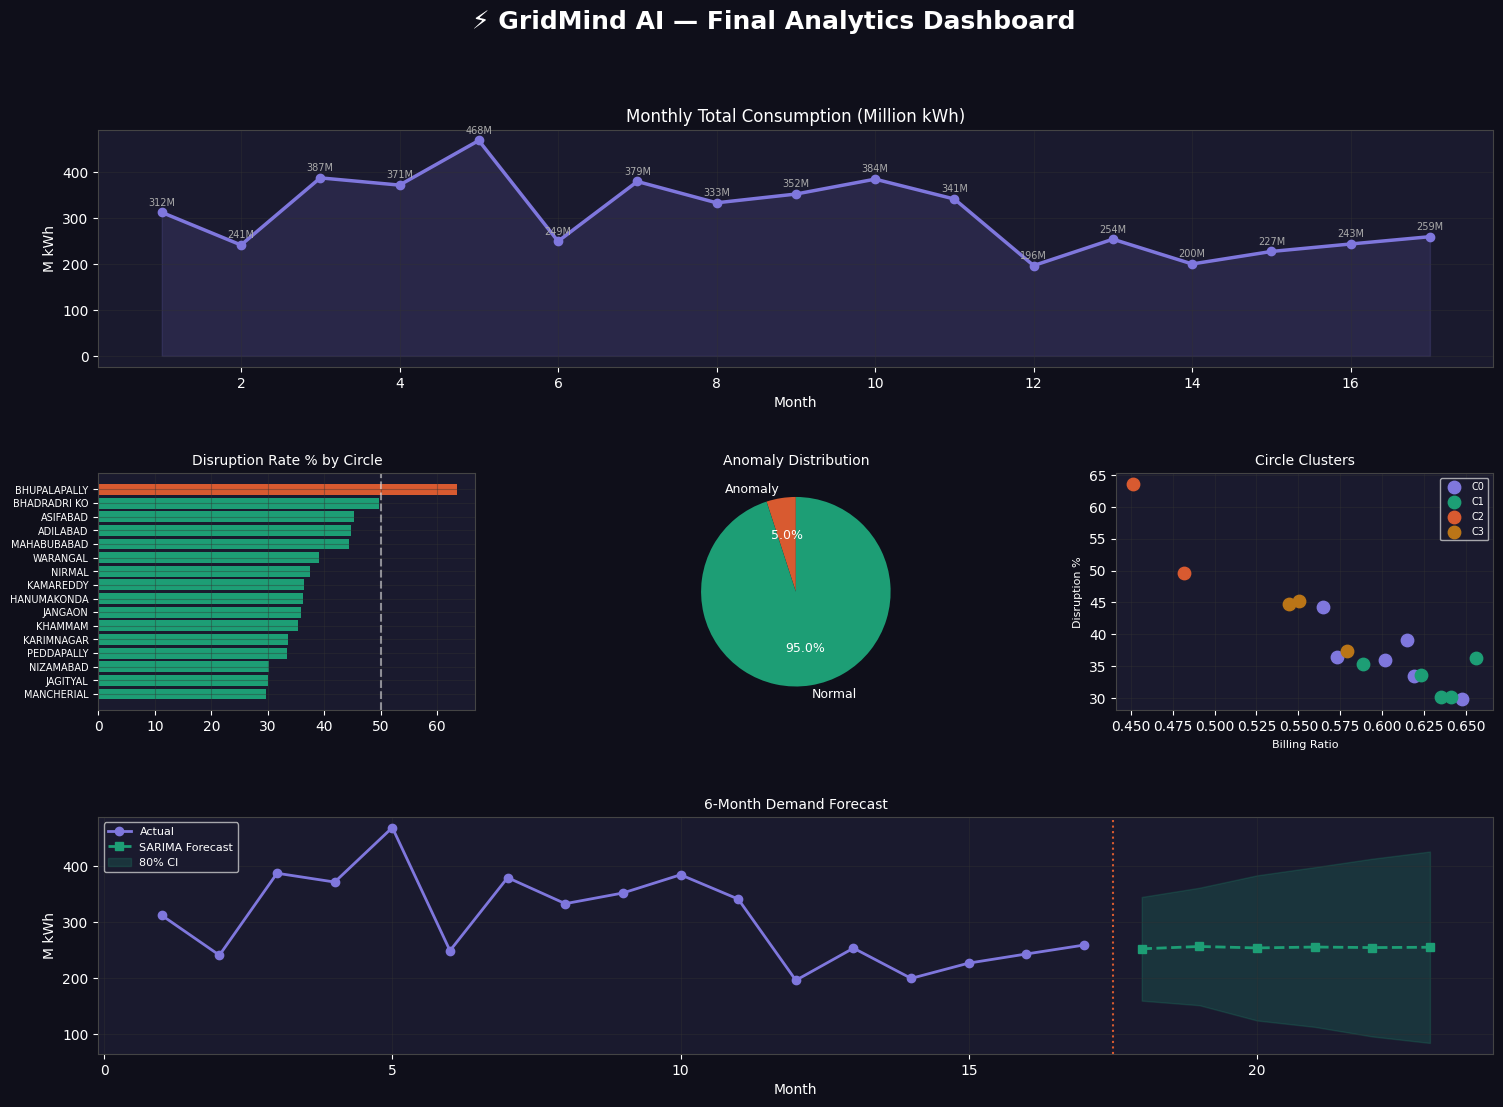

✅ Final dashboard saved as gridmind_dashboard.png


In [ ]:
# ── Final Summary Dashboard ───────────────────────────────────────
fig = plt.figure(figsize=(18, 12), facecolor='#0F0F1A')
fig.suptitle('⚡ GridMind AI — Final Analytics Dashboard', fontsize=18,
             color='white', fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1: Monthly trend
ax1 = fig.add_subplot(gs[0, :])
monthly = master.groupby('month_num')['Units'].sum()
ax1.plot(monthly.index, monthly.values/1e6, 'o-', color='#7F77DD', linewidth=2.5, markersize=6)
ax1.fill_between(monthly.index, monthly.values/1e6, alpha=0.15, color='#7F77DD')
ax1.set_title('Monthly Total Consumption (Million kWh)', color='white')
ax1.set_xlabel('Month'); ax1.set_ylabel('M kWh')
for m, v in zip(monthly.index, monthly.values/1e6):
    ax1.annotate(f'{v:.0f}M', (m, v), textcoords='offset points',
                 xytext=(0,5), fontsize=7, color='#AAA', ha='center')

# 2: Disruption rate per circle
ax2 = fig.add_subplot(gs[1, 0])
dis = master.groupby('Circle')['disruption'].mean().sort_values()
cols = ['#D85A30' if v > 0.5 else '#1D9E75' for v in dis.values]
ax2.barh(range(len(dis)), dis.values*100, color=cols)
ax2.set_yticks(range(len(dis)))
ax2.set_yticklabels([c[:12] for c in dis.index], fontsize=7)
ax2.axvline(50, color='white', linestyle='--', alpha=0.5)
ax2.set_title('Disruption Rate % by Circle', color='white', fontsize=10)

# 3: Anomaly pie
ax3 = fig.add_subplot(gs[1, 1])
sizes = [master['is_anomaly'].sum(), (master['is_anomaly']==0).sum()]
ax3.pie(sizes, labels=['Anomaly','Normal'], colors=['#D85A30','#1D9E75'],
        autopct='%1.1f%%', startangle=90,
        textprops={'color':'white','fontsize':9})
ax3.set_title('Anomaly Distribution', color='white', fontsize=10)

# 4: Cluster scatter
ax4 = fig.add_subplot(gs[1, 2])
clr = ['#7F77DD','#1D9E75','#D85A30','#BA7517']
for cl in range(4):
    sub = circle_agg[circle_agg['cluster']==cl]
    ax4.scatter(sub['avg_billing_ratio'], sub['disruption_rate']*100,
                s=80, c=clr[cl], label=f'C{cl}', zorder=5)
ax4.set_title('Circle Clusters', color='white', fontsize=10)
ax4.set_xlabel('Billing Ratio', fontsize=8); ax4.set_ylabel('Disruption %', fontsize=8)
ax4.legend(fontsize=7)

# 5: SARIMA forecast
ax5 = fig.add_subplot(gs[2, :])
fc = sarima_res.get_forecast(steps=6)
fc_vals = fc.predicted_mean
fc_ci   = fc.conf_int(alpha=0.2)
fmonths = list(range(monthly.index[-1]+1, monthly.index[-1]+7))
ax5.plot(monthly.index, monthly.values/1e6, 'o-', color='#7F77DD', linewidth=2, label='Actual')
ax5.plot(fmonths, fc_vals.values/1e6, 's--', color='#1D9E75', linewidth=2, label='SARIMA Forecast')
ax5.fill_between(fmonths, fc_ci.iloc[:,0]/1e6, fc_ci.iloc[:,1]/1e6,
                 alpha=0.2, color='#1D9E75', label='80% CI')
ax5.axvline(monthly.index[-1]+0.5, color='#D85A30', linestyle=':', linewidth=1.5)
ax5.set_title('6-Month Demand Forecast', color='white', fontsize=10)
ax5.set_xlabel('Month'); ax5.set_ylabel('M kWh')
ax5.legend(fontsize=8)

plt.savefig('gridmind_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0F0F1A')
plt.show()
print('✅ Final dashboard saved as gridmind_dashboard.png')


In [ ]:
# ── Final Summary Print ───────────────────────────────────────────
print('=' * 60)
print('   GRIDMIND AI — PROJECT COMPLETION SUMMARY')
print('=' * 60)
print(f'  Total records processed : {len(master):,}')
print(f'  Circles covered         : {master["Circle"].nunique()}')
print(f'  Monthly files merged    : 17')
print(f'  Anomalies detected      : {master["is_anomaly"].sum():,} ({master["is_anomaly"].mean()*100:.1f}%)')
print(f'  Disruption rate         : {master["disruption"].mean()*100:.1f}%')
print(f'  RF ROC-AUC              : {roc_auc_score(y_te, y_prob_rf):.4f}')
print(f'  SARIMA MAPE             : {mape_sarima:.2f}%')
print(f'  KMeans Silhouette       : {sil:.4f}')
print()
print('  Saved Files:')
for f in sorted(os.listdir('models')): print(f'    models/{f}')
for f in ['eda_overview.png','eda_heatmaps.png','eda_anomalies.png',
          'anomaly_results.png','rf_results.png','sarima_forecast.png',
          'kmeans_clusters.png','gridmind_dashboard.png','main.py']:
    print(f'    {f}')
print('=' * 60)
print('  ✅ GridMind AI Pipeline Complete!')
print('=' * 60)


   GRIDMIND AI — PROJECT COMPLETION SUMMARY
  Total records processed : 156,294
  Circles covered         : 16
  Monthly files merged    : 17
  Anomalies detected      : 7,815 (5.0%)
  Disruption rate         : 40.7%
  RF ROC-AUC              : 1.0000
  SARIMA MAPE             : 23.34%
  KMeans Silhouette       : 0.2610

  Saved Files:
    models/iso_forest.pkl
    models/kmeans.pkl
    models/rf_disruption.pkl
    models/sarima_model.pkl
    models/scaler_iso.pkl
    eda_overview.png
    eda_heatmaps.png
    eda_anomalies.png
    anomaly_results.png
    rf_results.png
    sarima_forecast.png
    kmeans_clusters.png
    gridmind_dashboard.png
    main.py
  ✅ GridMind AI Pipeline Complete!
